In [36]:
!pip install torchsummary opencv-python
!pip -q install mlflow

import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import math
import time
import copy
import itertools
import zipfile

import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import optim as torch_optim
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split, Dataset

import torchvision.transforms as T
from torchvision import transforms, datasets, models
import torchvision.models as tv_models
from torchvision import datasets, transforms, models

import mlflow
import mlflow.pytorch
from google.colab import drive



from pathlib import Path


drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:

#Pathes for Train, Test, Val
base_path = r"/content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized"
mask_path = r"/content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/masks_pred"

#Paths for External tEst case
ext_test_base_path = r"/content/drive/MyDrive/Masterarbeit/Classification_DS/output_external_ds/images_resized"
ext_test_base_path_mask = r"/content/drive/MyDrive/Masterarbeit/Classification_DS/output_external_ds/masks_pred"




for root, dirs, files in os.walk(base_path):
    print(f"\n Directory: {root}")
    if dirs:
        print("Subdirectories:", dirs)
    if files:
        print(len(files))
        print("Files:", files[:10])



 Directory: /content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized
Subdirectories: ['diabetic', 'masd', 'pressure', 'venous']

 Directory: /content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized/diabetic
Subdirectories: ['train', 'val', 'test']

 Directory: /content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized/diabetic/train
484
Files: ['azh_100.png', 'azh_10.png', 'azh_105.png', 'azh_11.png', 'azh_103.png', 'azh_107.png', 'azh_102.png', 'azh_106.png', 'azh_110.png', 'azh_111.png']

 Directory: /content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized/diabetic/val
104
Files: ['azh_1.png', 'azh_101.png', 'azh_108.png', 'azh_109.png', 'azh_13.png', 'azh_142.png', 'azh_131.png', 'azh_116.png', 'azh_113.png', 'azh_39.png']

 Directory: /content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized/diabetic/test
103
Files: ['azh_104.png', 'azh_123.png', 'azh

In [39]:

SEED = 42 # reproducability

  # contains class folders burns, diabetic, pressure, surgical, venous

NUM_CLASSES = 4
IN_CHANNELS = 3  # RGB
BATCH_SIZE = 28
NUM_WORKERS = 8

LR = 1e-3 # deprecated

NUM_EPOCHS = 40
EARLYSTOPPING_PATIENCE = 8

OUTPUT_DIR = "./eval_cls"

# Seeding for reproducibility
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    torch.use_deterministic_algorithms(True)

SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [40]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from pathlib import Path
from PIL import Image
import os

# =========================
# CONFIG
# =========================
USE_AUGMENTED = True
AUG_SPLIT_NAME = "train_aug"

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=imagenet_mean, std=imagenet_std),

])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=imagenet_mean, std=imagenet_std),

])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])


class WoundDatasetWithMask(Dataset):
    def __init__(self, samples, mask_folder_root, classes, class_to_idx, transform=None, mask_transform=None):
        self.samples = samples
        self.mask_folder_root = Path(mask_folder_root)
        self.classes = classes
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.samples)

    def _find_mask(self, image_path_str):
        image_path = Path(image_path_str)
        image_name = image_path.stem

        is_external_test = (str(self.mask_folder_root) == str(ext_test_base_path_mask))

        if is_external_test:
            wound_type = image_path.parent.name
            mask_search_dir = self.mask_folder_root / wound_type
        else:
            split_type = image_path.parent.name
            wound_type = image_path.parent.parent.name
            mask_search_dir = self.mask_folder_root / wound_type / split_type

        possible_mask_names = [
            f"{image_name}.png",
            f"{image_name}.jpg",
            f"{image_name}_mask.png",
            f"{image_name}_mask.jpg",
        ]

        for mask_name in possible_mask_names:
            candidate = mask_search_dir / mask_name
            if candidate.exists():
                return str(candidate)

        return None

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        mask_path = self._find_mask(image_path)
        if mask_path and os.path.exists(mask_path):
            mask = Image.open(mask_path).convert("L")
        else:
            mask = Image.new("L", image.size, 255)
            print(f"WARNING: Using default white mask for image: {image_path}")

        if self.transform:
            image = self.transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.ToTensor(),
            ])(mask)

        mask = (mask > 0.5).float()
        return image, mask, label



def collect_samples_train_with_fallback(
    base_path,
    train_split="train",
    aug_split="train_aug",
    use_augmented=True,
    other_splits=("val", "test"),
    exts=(".jpg", ".jpeg", ".png", ".bmp", ".gif"),
):
    base = Path(base_path)
    class_names = sorted([d.name for d in base.iterdir() if d.is_dir() and not d.name.startswith(".")])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

    samples = {train_split: [], "val": [], "test": []}

    def list_imgs(folder: Path):
        if not folder.is_dir():
            return []
        files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts]
        return sorted(files)

    for cls in class_names:
        cls_dir = base / cls
        label = class_to_idx[cls]

        chosen_train_dir = cls_dir / train_split
        if use_augmented:
            aug_dir = cls_dir / aug_split
            aug_imgs = list_imgs(aug_dir)
            if len(aug_imgs) > 0:
                chosen_train_dir = aug_dir

        for p in list_imgs(chosen_train_dir):
            samples[train_split].append((str(p), label))

        for sp in other_splits:
            sp_dir = cls_dir / sp
            for p in list_imgs(sp_dir):
                samples[sp].append((str(p), label))

    return class_names, class_to_idx, samples

# Laden von train_aug wenn da sonst train
class_names, class_to_idx, samples = collect_samples_train_with_fallback(
    base_path=base_path,
    train_split="train",
    aug_split=AUG_SPLIT_NAME,
    use_augmented=USE_AUGMENTED,
    other_splits=("val", "test"),
)

train_samples = samples["train"]
val_samples = samples["val"]
test_samples = samples["test"]

print("Using per-class train_aug fallback:", USE_AUGMENTED)
print(f"Classes: {class_names}")
print(f"Train size: {len(train_samples)}, Val size: {len(val_samples)}, Test size: {len(test_samples)}")




train_dataset = WoundDatasetWithMask(
    samples=train_samples,
    mask_folder_root=mask_path,
    classes=class_names,
    class_to_idx=class_to_idx,
    transform=train_transform,
    mask_transform=mask_transform
)

val_dataset = WoundDatasetWithMask(
    samples=val_samples,
    mask_folder_root=mask_path,
    classes=class_names,
    class_to_idx=class_to_idx,
    transform=val_transform,
    mask_transform=mask_transform
)

test_dataset = WoundDatasetWithMask(
    samples=test_samples,
    mask_folder_root=mask_path,
    classes=class_names,
    class_to_idx=class_to_idx,
    transform=test_transform,
    mask_transform=mask_transform
)


g_loader = torch.Generator()
g_loader.manual_seed(SEED)
# Seed für worker
def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0, # für reproduciblity danach hoch stellen
    worker_init_fn=seed_worker,
    generator=g_loader,
    persistent_workers=False,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    worker_init_fn=seed_worker,
    persistent_workers=False,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    worker_init_fn=seed_worker,
    persistent_workers=False,
    pin_memory=True,
)

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
}

Using per-class train_aug fallback: True
Classes: ['diabetic', 'masd', 'pressure', 'venous']
Train size: 2126, Val size: 391, Test size: 387


In [41]:


ext_test_samples = []

for wound_type_name in class_names:
    wound_type_path = Path(ext_test_base_path) / wound_type_name
    label_idx = class_to_idx[wound_type_name]

    if wound_type_path.is_dir():
        for img_file in sorted(wound_type_path.glob("*")):
            if img_file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
                ext_test_samples.append((str(img_file), label_idx))

# Create the external test dataset
ext_test_dataset = WoundDatasetWithMask(
    samples=ext_test_samples,
    mask_folder_root=ext_test_base_path_mask,
    classes=class_names,
    class_to_idx=class_to_idx,
    transform=test_transform, # Use the existing test_transform
    mask_transform=mask_transform
)

# Create the external test DataLoader
ext_test_loader = DataLoader(
    ext_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    worker_init_fn=seed_worker,
    persistent_workers=False,
    pin_memory=True,
)


In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ==========================================================
# Soft-Guided Attention EfficientNet
# ==========================================================
class SoftGuidedAttentionEfficientNet(nn.Module):
    """
    EfficientNet Backbone + Soft-Guided Attention

    - Nutzt Mid- und High-Level Features der EfficientNet Backbone.
    - Erzeugt Attention Maps (Pixel-Relevanz für die Klassifikation).
    - Optional wird eine Input-Maske genutzt, um die wichtigen Regionen
      (ROI) stärker zu gewichten.
    - Kombiniert globale Feature-Pooling + maskenfokussiertes ROI-Pooling
      für die finale Klassifikation.
    """
    def __init__(
        self,
        num_classes,
        variant="efficientnet_b3",
        pretrained=True,
        mask_resize_var=1.0,          # Skalierung der Maske beim Resize
        attention_strength=0.75,      # Wie stark die Attention Features übernommen werden
        attention_power=1.15,         # Potenz, um Attention Map stärker zu betonen
        attention_threshold=0.0,      # kleine Attention Werte werden ggf. auf 0 gesetzt
        use_residual=True,            # Residual Connection einbeziehen, um Original-Features zu erhalten
        mask_alpha=0.38,              # Gewicht von Maske vs Attention
        bg_floor=0.55,                # minimaler Wert für Hintergrund
        roi_boost=1.10,               # Verstärkung für die ROI-Pool Features
        roi_pool_temperature=1.0,     # Power, die beim ROI-Pooling auf Masken angewendet wird
        mid_idx=6,                     # Index des mittleren Feature-Layers
        hi_idx=8                       # Index des hohen Feature-Layers
    ):
        super().__init__()
        self.mask_resize_var = float(mask_resize_var)
        self.attention_strength = float(attention_strength)
        self.attention_power = float(attention_power)
        self.attention_threshold = float(attention_threshold)
        self.use_residual = bool(use_residual)
        self.mask_alpha = float(mask_alpha)
        self.bg_floor = float(bg_floor)
        self.roi_boost = float(roi_boost)
        self.roi_pool_temperature = float(roi_pool_temperature)


        weights = None
        if pretrained:
            weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1

        backbone = models.efficientnet_b3(weights=weights)
        self.backbone_features = backbone.features  # Liste der Feature Blöcke

        self.mid_idx = int(mid_idx)
        self.hi_idx = int(hi_idx)

        #Check Layer indizees
        if not (0 <= self.mid_idx < len(self.backbone_features)):
            raise ValueError("mid_idx ist außerhalb der backbone.features Länge")
        if not (0 <= self.hi_idx < len(self.backbone_features)):
            raise ValueError("hi_idx ist außerhalb der backbone.features Länge")
        if self.mid_idx >= self.hi_idx:
            raise ValueError("mid_idx muss kleiner als hi_idx sein")


        mid_channels, hi_channels = self._infer_channels() # determine mid and hi feature channels


        # Mid-Level-Attention
        self.attention_conv_mid = nn.Sequential(
            nn.Conv2d(mid_channels, max(32, mid_channels // 4), kernel_size=1),
            nn.BatchNorm2d(max(32, mid_channels // 4)),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(max(32, mid_channels // 4), max(16, mid_channels // 8), kernel_size=1),
            nn.BatchNorm2d(max(16, mid_channels // 8)),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(16, mid_channels // 8), 1, kernel_size=1),
            nn.Sigmoid()  # Attention Map zwischen 0 und 1
        )

        # High-Level Attention
        self.attention_conv_hi = nn.Sequential(
            nn.Conv2d(hi_channels, max(64, hi_channels // 4), kernel_size=1),
            nn.BatchNorm2d(max(64, hi_channels // 4)),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(max(64, hi_channels // 4), max(32, hi_channels // 8), kernel_size=1),
            nn.BatchNorm2d(max(32, hi_channels // 8)),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(32, hi_channels // 8), 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(hi_channels * 2, num_classes)  # global + ROI Features


    # Helper determine num channels
    def _infer_channels(self):
        """
        Dummy-Input durch Backbone laufen lassen, um Anzahl Channels
        in mid- und hi-Feature Maps zu bestimmen.
        """
        self.eval()
        with torch.no_grad():
            x = torch.zeros(1, 3, 256, 256)  # Dummy-Batch
            feat_mid = None
            feat_hi = None
            for i, block in enumerate(self.backbone_features):
                x = block(x)
                if i == self.mid_idx:
                    feat_mid = x
                if i == self.hi_idx:
                    feat_hi = x
            if feat_mid is None or feat_hi is None:
                raise RuntimeError("Konnte Feature Maps nicht inferieren, prüfe Indizes")
            return int(feat_mid.shape[1]), int(feat_hi.shape[1])


    @staticmethod
    def _ensure_mask_4d(mask: torch.Tensor) -> torch.Tensor:
        if mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)
        elif mask.dim() == 3:
            mask = mask.unsqueeze(1)
        return mask

    # Resize Mask to Feature Map
    def _resize_mask(self, mask: torch.Tensor, h: int, w: int) -> torch.Tensor:
        mask = SoftGuidedAttentionEfficientNet._ensure_mask_4d(mask)
        mask = F.interpolate(mask, size=(h, w), mode="bilinear", align_corners=False)
        return (mask * self.mask_resize_var).clamp(0.0, 1.0)  # Werte zwischen 0-1


    # Soft gated Mask für Pooling
    def _soft_mask_gate(self, m: torch.Tensor) -> torch.Tensor:
        """
        Verstärkt die ROI-Maske, Background-Werte werden auf bg_floor gesetzt,
        ROI wird mit roi_boost verstärkt.
        """
        return self.bg_floor + (self.roi_boost - self.bg_floor) * m


    # Combine Attention and Mask
    def _combine_mask_and_attention(self, att: torch.Tensor, m: torch.Tensor) -> torch.Tensor:
        """
        Kombiniert Attention Map mit Maske (soft-guided)
        """
        mask_gate = self._soft_mask_gate(m)
        combined = self.mask_alpha * mask_gate + (1.0 - self.mask_alpha) * att

        if self.attention_power != 1.0:
            combined = torch.pow(combined + 1e-8, self.attention_power)  # stärker betonen

        if self.attention_threshold > 0.0:
            # kleine Werte auf Null setzen
            combined = torch.where(
                combined > self.attention_threshold,
                combined,
                torch.zeros_like(combined)
            )

        return combined


    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        feat_mid = None
        feat_hi = None

        # ------------------------
        # Backbone Features berechnen
        # ------------------------
        for i, block in enumerate(self.backbone_features):
            x = block(x)
            if i == self.mid_idx:
                feat_mid = x
            if i == self.hi_idx:
                feat_hi = x

        if feat_mid is None or feat_hi is None:
            raise RuntimeError("Feature Maps sind None, prüfe Indizes")

        # ------------------------
        # Mid-Level Attention
        # ------------------------
        att_mid = self.attention_conv_mid(feat_mid)
        if mask is not None:
            m_mid = self._resize_mask(mask, feat_mid.shape[2], feat_mid.shape[3])
            gate_mid = self._combine_mask_and_attention(att_mid, m_mid)
            attended_mid = feat_mid * gate_mid
            if self.use_residual:
                attended_mid = attended_mid + 0.1 * feat_mid
            feat_mid = self.attention_strength * attended_mid + (1.0 - self.attention_strength) * feat_mid
        else:
            gate_mid = att_mid
            if self.attention_power != 1.0:
                gate_mid = torch.pow(gate_mid + 1e-8, self.attention_power)
            attended_mid = feat_mid * gate_mid
            if self.use_residual:
                attended_mid = attended_mid + 0.1 * feat_mid
            feat_mid = self.attention_strength * attended_mid + (1.0 - self.attention_strength) * feat_mid

        # ------------------------
        # High-Level Features
        # ------------------------
        x = feat_mid
        for i in range(self.mid_idx + 1, self.hi_idx + 1):
            x = self.backbone_features[i](x)
        features = x

        att_hi = self.attention_conv_hi(features)

        if mask is not None:
            m_hi = self._resize_mask(mask, features.shape[2], features.shape[3])
            gate_hi = self._combine_mask_and_attention(att_hi, m_hi)
            attended_hi = features * gate_hi
            if self.use_residual:
                attended_hi = attended_hi + 0.1 * features
            features = self.attention_strength * attended_hi + (1.0 - self.attention_strength) * features

            pooled_global = self.avgpool(features).flatten(1)

            roi_weight = self._soft_mask_gate(m_hi)
            if self.roi_pool_temperature != 1.0:
                roi_weight = torch.pow(roi_weight + 1e-8, self.roi_pool_temperature)

            pooled_roi = self.avgpool(features * roi_weight).flatten(1)
        else:
            gate_hi = att_hi
            if self.attention_power != 1.0:
                gate_hi = torch.pow(gate_hi + 1e-8, self.attention_power)
            attended_hi = features * gate_hi
            if self.use_residual:
                attended_hi = attended_hi + 0.1 * features
            features = self.attention_strength * attended_hi + (1.0 - self.attention_strength) * features

            pooled_global = self.avgpool(features).flatten(1)
            pooled_roi = pooled_global

        # ------------------------
        # Global + ROI Features zusammenführen
        # ------------------------
        pooled = torch.cat([pooled_global, pooled_roi], dim=1)
        out = self.classifier(pooled)
        return out




model = SoftGuidedAttentionEfficientNet(
    num_classes=NUM_CLASSES,
    variant="efficientnet_b3",
    pretrained=True,
    mask_resize_var=1.0,
    attention_strength=0.75,
    attention_power=1.15,
    attention_threshold=0.0,
    use_residual=True,
    mask_alpha=0.38,
    bg_floor=0.55,
    roi_boost=1.10,
    roi_pool_temperature=1.0,
    mid_idx=6,
    hi_idx=8
).to(device)

# Backbone einfrieren, nur Attention + Classifier trainieren
for p in model.parameters():
    p.requires_grad = False

for name, p in model.named_parameters():
    if ("attention" in name) or ("classifier" in name):
        p.requires_grad = True

# Optional: Letzte n Backbone-Blöcke freigeben
unfreeze_last_n = 3
for i in range(len(model.backbone_features) - unfreeze_last_n, len(model.backbone_features)):
    for p in model.backbone_features[i].parameters():
        p.requires_grad = True

# Parameter nach Lernrate gruppieren
backbone_params = []
attention_params = []
head_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "backbone_features" in name:
        backbone_params.append(p)
    elif "attention" in name:
        attention_params.append(p)
    else:
        head_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 5e-5, "weight_decay": 1e-4},
        {"params": attention_params, "lr": 4e-4, "weight_decay": 1e-4},
        {"params": head_params, "lr": 1.5e-3, "weight_decay": 1e-4},
    ]
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

In [43]:


class EarlyStopping:
    def __init__(self, patience=5, mode="max", min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.mode = mode
        self.min_delta = float(min_delta)
        self.restore_best_weights = restore_best_weights

        self.best_score = -math.inf if mode == "max" else math.inf
        self.best_state = None
        self.counter = 0
        self.early_stop = False
        self.best_epoch = 0

    def _is_improvement(self, score: float) -> bool:
        if self.mode == "max":
            return score > self.best_score + self.min_delta
        return score < self.best_score - self.min_delta

    def __call__(self, score, model, epoch):
        if self._is_improvement(float(score)):
            self.best_score = float(score)
            self.counter = 0
            self.best_epoch = epoch
            if self.restore_best_weights:
                self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore(self, model):
        if self.restore_best_weights and self.best_state is not None:
            model.load_state_dict(self.best_state)

early_stopping = EarlyStopping(
    patience=EARLYSTOPPING_PATIENCE,
    mode="max",
    min_delta=1e-4,
    restore_best_weights=True
)

In [44]:
def run_epoch(model, loader, phase):
    is_train = phase == "train"
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, masks, labels in loader:  # Changed: unpack masks
        inputs = inputs.to(device)
        masks = masks.to(device)  # Added: move masks to device
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs, masks)  # Changed: pass masks to model
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    epoch_loss = running_loss / max(1, len(loader.dataset))

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, acc, f1, all_labels, all_preds

In [45]:


run_name = f"resnet50_attention_cls_bs{BATCH_SIZE}_lr{LR}_{int(time.time())}"

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

with mlflow.start_run(run_name=run_name):
    mlflow.log_params(
        {
            "seed": SEED,
            "data_dir": base_path,
            "mask_dir": mask_path,
            "num_classes": NUM_CLASSES,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "epochs": NUM_EPOCHS,
            "earlystopping_patience": EARLYSTOPPING_PATIENCE,
            "earlystopping_mode": "max",
            "earlystopping_metric": "val_f1_macro",
            "earlystopping_min_delta": 1e-4,
            "optimizer": "AdamW",
            "loss": "CrossEntropyLoss",
            "model": "ResNet50_AttentionMask",
        }
    )

    since = time.time()

    best_val_f1 = float("-inf")
    best_val_report = None
    best_val_confusion = None

    for epoch in range(NUM_EPOCHS):
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")

        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, phase="train")
        val_loss, val_acc, val_f1, val_labels, val_preds = run_epoch(model, val_loader, phase="val")

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        mlflow.log_metric("train_loss", float(train_loss), step=epoch + 1)
        mlflow.log_metric("train_acc", float(train_acc), step=epoch + 1)
        mlflow.log_metric("train_f1_macro", float(train_f1), step=epoch + 1)

        mlflow.log_metric("val_loss", float(val_loss), step=epoch + 1)
        mlflow.log_metric("val_acc", float(val_acc), step=epoch + 1)
        mlflow.log_metric("val_f1_macro", float(val_f1), step=epoch + 1)

        print(
            f"  train_loss {train_loss:.4f} "
            f"val_loss {val_loss:.4f} "
            f"val_acc {val_acc:.4f} "
            f"val_f1 {val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = float(val_f1)
            best_val_report = classification_report(
                val_labels,
                val_preds,
                target_names=class_names,
                digits=4,
            )
            best_val_confusion = confusion_matrix(val_labels, val_preds)

        early_stopping(float(val_f1), model, epoch + 1)

        if early_stopping.early_stop:
            print(
                f"Early stopping at epoch {epoch + 1}, "
                f"best epoch was {early_stopping.best_epoch}"
            )
            break

    early_stopping.restore(model)

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val macro F1 (early stopping): {early_stopping.best_score:.4f}")
    print(f"Restored weights from epoch: {early_stopping.best_epoch}")

    mlflow.log_param("restored_best_epoch", int(early_stopping.best_epoch))
    mlflow.log_metric("restored_best_score", float(early_stopping.best_score), step=int(early_stopping.best_epoch))

    history_df = pd.DataFrame(history)
    best_epoch_data = history_df[history_df["epoch"] == early_stopping.best_epoch]

    if not best_epoch_data.empty:
        final_val_acc_best_epoch = float(best_epoch_data["val_acc"].values[0])
        final_val_f1_best_epoch = float(best_epoch_data["val_f1"].values[0])

        mlflow.log_metric(
            "final_val_acc_best_epoch",
            final_val_acc_best_epoch,
            step=int(early_stopping.best_epoch),
        )
        mlflow.log_metric(
            "final_val_f1_best_epoch",
            final_val_f1_best_epoch,
            step=int(early_stopping.best_epoch),
        )

    # Log model after restore
    mlflow.pytorch.log_model(model, artifact_path="model")

    if best_val_report is not None:
        mlflow.log_text(best_val_report, "val_classification_report.txt")

    if best_val_confusion is not None:
        cm_df = pd.DataFrame(
            best_val_confusion,
            index=[f"true_{c}" for c in class_names],
            columns=[f"pred_{c}" for c in class_names],
        )
        mlflow.log_dict(cm_df.to_dict(), "val_confusion_matrix.json")

print("Training complete.")

Epoch 1/40
  train_loss 0.7189 val_loss 0.6970 val_acc 0.7980 val_f1 0.7272
Epoch 2/40
  train_loss 0.4366 val_loss 1.8345 val_acc 0.8184 val_f1 0.7568
Epoch 3/40
  train_loss 0.3545 val_loss 1.4975 val_acc 0.8517 val_f1 0.8145
Epoch 4/40
  train_loss 0.3173 val_loss 4.4779 val_acc 0.8645 val_f1 0.8320
Epoch 5/40
  train_loss 0.2817 val_loss 0.5751 val_acc 0.8645 val_f1 0.8258
Epoch 6/40
  train_loss 0.2675 val_loss 3.5333 val_acc 0.8721 val_f1 0.8320
Epoch 7/40
  train_loss 0.2705 val_loss 3.7548 val_acc 0.8645 val_f1 0.8417
Epoch 8/40
  train_loss 0.2518 val_loss 1.8816 val_acc 0.8747 val_f1 0.8508
Epoch 9/40
  train_loss 0.2502 val_loss 1.0350 val_acc 0.8696 val_f1 0.8520
Epoch 10/40
  train_loss 0.2430 val_loss 2.2404 val_acc 0.8747 val_f1 0.8498
Epoch 11/40
  train_loss 0.2357 val_loss 3.5782 val_acc 0.8772 val_f1 0.8687
Epoch 12/40
  train_loss 0.2366 val_loss 1.5126 val_acc 0.8747 val_f1 0.8559
Epoch 13/40
  train_loss 0.2303 val_loss 0.5879 val_acc 0.8721 val_f1 0.8426
Epoch 14

2026/03/05 09:33:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 09:33:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  train_loss 0.2189 val_loss 5.1840 val_acc 0.9028 val_f1 0.8879
Early stopping at epoch 29, best epoch was 21
Training complete in 14m 43s
Best val macro F1 (early stopping): 0.8905
Restored weights from epoch: 21


2026/03/05 09:33:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/05 09:33:32 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Training complete.


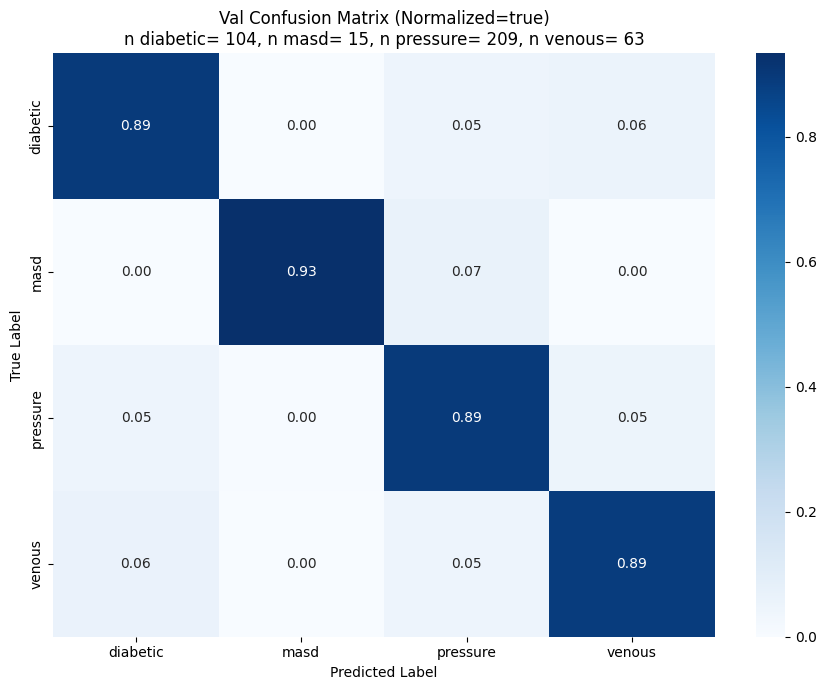

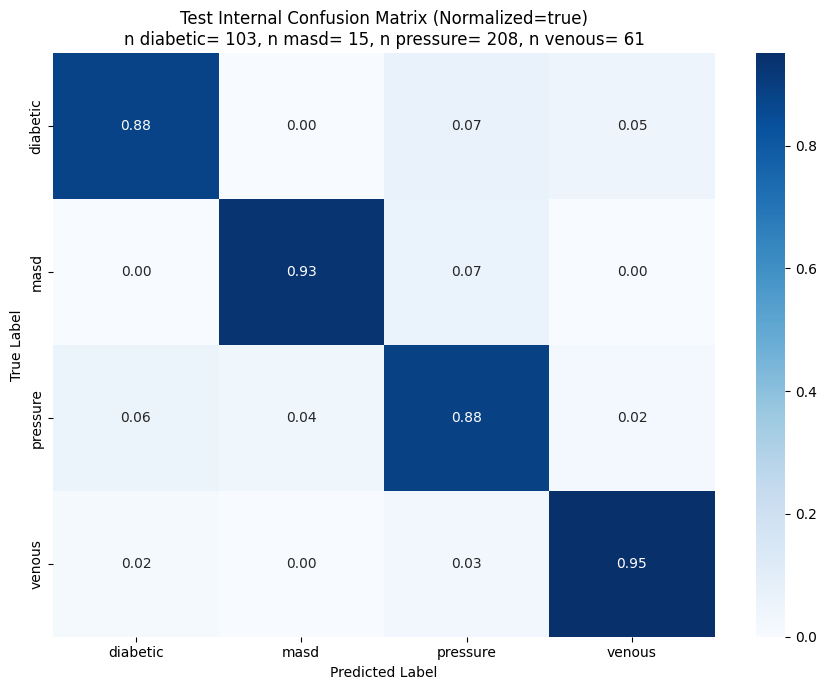

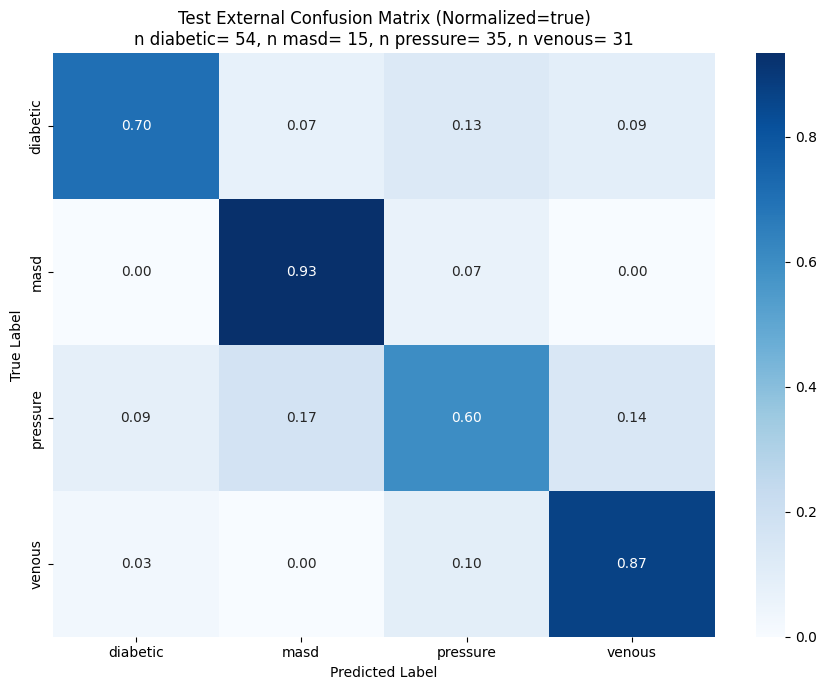

Val Results
Accuracy: 0.8951
Macro F1 : 0.8905
Support : n diabetic= 104, n masd= 15, n pressure= 209, n venous= 63

Test Internal Results
Accuracy: 0.8966
Macro F1 : 0.8644
Support : n diabetic= 103, n masd= 15, n pressure= 208, n venous= 61

Test External Results
Accuracy: 0.7407
Macro F1 : 0.7326
Support : n diabetic= 54, n masd= 15, n pressure= 35, n venous= 31

Val Classification Report:
               precision    recall  f1-score   support

    diabetic     0.8692    0.8942    0.8815       104
        masd     0.9333    0.9333    0.9333        15
    pressure     0.9541    0.8947    0.9235       209
      venous     0.7671    0.8889    0.8235        63

    accuracy                         0.8951       391
   macro avg     0.8809    0.9028    0.8905       391
weighted avg     0.9006    0.8951    0.8966       391

Test Internal Classification Report:
               precision    recall  f1-score   support

    diabetic     0.8750    0.8835    0.8792       103
        masd     0.63

In [46]:
def evaluate_split(
    model,
    dataloader,
    class_names,
    split_name="Val",
    device=None,
    normalize="true",  # "true" row normalized, "pred" col normalized, "all" global, None raw counts
    show_plots=True,
):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    all_labels = []
    all_preds = []

    for batch in dataloader:
        # batch can be: (images, labels) or (images, masks, labels) or dict
        if isinstance(batch, (tuple, list)):
            if len(batch) == 2:
                images, labels = batch
                masks = None
            elif len(batch) == 3:
                images, masks, labels = batch
            else:
                raise ValueError(f"Unexpected batch tuple length: {len(batch)}")
        elif isinstance(batch, dict):
            images = batch.get("image") or batch.get("images")
            masks = batch.get("mask") or batch.get("masks")
            labels = batch.get("label") or batch.get("labels")
            if images is None or labels is None:
                raise ValueError("Dict batch must contain image(s) and label(s)")
        else:
            raise ValueError(f"Unsupported batch type: {type(batch)}")

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if masks is not None:
            masks = masks.to(device, non_blocking=True)
            logits = model(images, masks)
        else:
            logits = model(images)

        preds = torch.argmax(logits, dim=1)
        all_labels.append(labels.detach().cpu())
        all_preds.append(preds.detach().cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    # counts per true class
    support = np.bincount(y_true, minlength=len(class_names))
    support_text = ", ".join([f"n {name}= {int(n)}" for name, n in zip(class_names, support)])

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

    if normalize is None:
        cm_show = cm.astype(np.float32)
        fmt = "d"
        title = f"{split_name} Confusion Matrix (Counts)\n{support_text}"
    else:
        cm_show = cm.astype(np.float32)
        if normalize == "true":
            denom = cm_show.sum(axis=1, keepdims=True)
        elif normalize == "pred":
            denom = cm_show.sum(axis=0, keepdims=True)
        elif normalize == "all":
            denom = cm_show.sum()
        else:
            raise ValueError("normalize must be one of: 'true', 'pred', 'all', None")

        cm_show = cm_show / (denom + 1e-12)
        fmt = ".2f"
        title = f"{split_name} Confusion Matrix (Normalized={normalize})\n{support_text}"

    if show_plots:
        plt.figure(figsize=(9, 7))
        sns.heatmap(
            cm_show,
            annot=True,
            fmt=fmt,
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues",
            cbar=True,
        )
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    summary_text = (
        f"{split_name} Results\n"
        f"Accuracy: {acc:.4f}\n"
        f"Macro F1 : {f1:.4f}\n"
        f"Support : {support_text}\n"
    )

    return {
        "split": split_name,
        "acc": acc,
        "f1_macro": f1,
        "report": report,
        "cm_counts": cm,
        "cm_display": cm_show,
        "y_true": y_true,
        "y_pred": y_pred,
        "support": support,
        "summary": summary_text,
    }


def evaluate_all_splits(model, val_loader, test_loader, ext_test_loader, class_names, device=None):
    results = {}

    results["val"] = evaluate_split(
        model, val_loader, class_names, split_name="Val", device=device, normalize="true", show_plots=True
    )
    results["test_internal"] = evaluate_split(
        model, test_loader, class_names, split_name="Test Internal", device=device, normalize="true", show_plots=True
    )
    results["test_external"] = evaluate_split(
        model, ext_test_loader, class_names, split_name="Test External", device=device, normalize="true", show_plots=True
    )

    print(results["val"]["summary"])
    print(results["test_internal"]["summary"])
    print(results["test_external"]["summary"])

    print("Val Classification Report:\n", results["val"]["report"])
    print("Test Internal Classification Report:\n", results["test_internal"]["report"])
    print("Test External Classification Report:\n", results["test_external"]["report"])

    return results


# Usage
device = next(model.parameters()).device
results = evaluate_all_splits(model, val_loader, test_loader, ext_test_loader, class_names, device=device)



In [47]:

device = next(model.parameters()).device

val_y_true = results["val"]["y_true"]
val_y_pred = results["val"]["y_pred"]

ext_test_y_true = results["test_external"]["y_true"]
ext_test_y_pred = results["test_external"]["y_pred"]


ext_correct_indices = np.where(ext_test_y_true == ext_test_y_pred)[0]
ext_incorrect_indices = np.where(ext_test_y_true != ext_test_y_pred)[0]


print(f"Found {len(ext_correct_indices)} correctly classified images in external test set.")
print(f"Found {len(ext_incorrect_indices)} incorrectly classified images in external test set.")

# Deterministic sampling
rng = np.random.default_rng(SEED)


selected_ext_correct_indices = rng.choice(
    ext_correct_indices,
    len(ext_correct_indices),
    replace=False
)
selected_ext_incorrect_indices = rng.choice(
    ext_incorrect_indices,
    len(ext_incorrect_indices),
    replace=False
)


print(f"Selected {len(selected_ext_correct_indices)} ext correct examples: {selected_ext_correct_indices}")
print(f"Selected {len(selected_ext_incorrect_indices)} ext incorrect examples: {selected_ext_incorrect_indices}")


Found 100 correctly classified images in external test set.
Found 35 incorrectly classified images in external test set.
Selected 100 ext correct examples: [130 110 108  71 101  98  87 121  62  82 105  10  80  90  13 120  14  47
 122  43  84  41  24 112  25  26 100  66 133 129  46 116  16  40 128  22
  77  35  54  45  28  33 126  42 123 115  59 134 107   7 127  79 125  63
  72  32  23  20  78  39  29   1  91 111  68  52  12  53 119  60  56  74
  11  57  86  50  67  70  49  15 131  19   9  64 124  55  65  96  34  85
  58  83 102 104 106   0 109  27 113  21]
Selected 35 ext incorrect examples: [ 95  36  73 117  17  99   8  44  31  37 103  81  75   6  92  18  94 132
  88  97 114   3  48 118   4  51   5  69  30  38  76  89  61  93   2]


In [48]:
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt



def get_image_data(dataset, preds, index, class_names, device):

    img, mask, label = dataset[int(index)]

    label_idx = int(label.item()) if isinstance(label, torch.Tensor) else int(label)
    pred_idx = int(preds[int(index)])

    return {
        "img": img.unsqueeze(0).to(device),
        "mask": mask.unsqueeze(0).to(device),
        "true_idx": label_idx,
        "pred_idx": pred_idx,
        "true_name": class_names[label_idx],
        "pred_name": class_names[pred_idx],
        "correct": label_idx == pred_idx
    }


class AttentionMaskGradCAM:

    def __init__(self, model):

        self.model = model
        self.layer = model.backbone_features[model.hi_idx]

        self.activations = None
        self.gradients = None

        self.hook = self.layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inp, out):

        if not isinstance(out, torch.Tensor):
            return

        self.activations = out

        if not out.requires_grad:
            return

        def grad_hook(grad):
            self.gradients = grad

        out.register_hook(grad_hook)

    def remove(self):

        if self.hook is not None:
            self.hook.remove()

    def __call__(self, img, mask, target_class):

        self.model.eval()
        self.model.zero_grad()

        self.activations = None
        self.gradients = None

        with torch.enable_grad():

            img = img.clone().detach().requires_grad_(True)

            logits = self.model(img, mask)
            score = logits[0, target_class]

            score.backward()

        if self.activations is None:
            raise RuntimeError("No activations captured")

        if self.gradients is None:
            raise RuntimeError("No gradients captured")

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=img.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[0,0]

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()


# --- Helfer Funktionen
def tensor_to_img(img_tensor):

    img = img_tensor[0].cpu().permute(1,2,0).numpy()
    return np.clip(img,0,1)


def resize_mask(mask_tensor, shape):

    mask = mask_tensor[0,0].cpu().numpy()
    return cv2.resize(mask, shape, interpolation=cv2.INTER_NEAREST)


def overlay_mask(img, mask, alpha=0.6):

    h,w,_ = img.shape
    mask = resize_mask(mask,(w,h))

    green = np.zeros_like(img)
    green[:,:,1] = 1

    active = mask > 0.5

    out = img.copy()
    out[active] = img[active]*(1-alpha) + green[active]*alpha

    return out


def overlay_cam(img, cam):

    h,w,_ = img.shape

    cam = cv2.resize(cam,(w,h))

    heat = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat,cv2.COLOR_BGR2RGB) / 255.0

    return img*0.6 + heat*0.4


def overlay_cam_mask(img, cam, mask):

    base = overlay_mask(img,mask)
    return overlay_cam(base,cam)


def visualize_attention_gradcam(
        model,
        dataset,
        preds,
        indices,
        class_names,
        device):

    gradcam = AttentionMaskGradCAM(model)

    try:

        for idx in indices:

            data = get_image_data(dataset,preds,idx,class_names,device)

            img = data["img"]
            mask = data["mask"]

            with torch.no_grad():

                logits = model(img,mask)
                probs = torch.softmax(logits,1)[0].cpu().numpy()

            cam = gradcam(img,mask,data["pred_idx"])


            img_np = tensor_to_img(img)

            mask_overlay = overlay_mask(img_np,mask)
            combined = overlay_cam_mask(img_np,cam,mask)

            plt.figure(figsize=(20,4))

            plt.subplot(1,5,1)
            plt.imshow(img_np)
            plt.title(f"Original\nTrue: {data['true_name']}")
            plt.axis("off")

            plt.subplot(1,5,2)
            plt.imshow(mask_overlay)
            plt.title("Input Mask")
            plt.axis("off")

            plt.subplot(1,5,3)
            plt.imshow(cam,cmap="jet")
            plt.title("GradCAM")
            plt.axis("off")

            plt.subplot(1,5,4)

            status = "Correct" if data["correct"] else "Incorrect"

            plt.imshow(combined)
            plt.title(
                f"Combined\nPred: {data['pred_name']} ({status})"
            )
            plt.axis("off")

            plt.subplot(1,5,5)

            y = np.arange(len(probs))
            bars = plt.barh(y,probs,color="gray")

            bars[data["pred_idx"]].set_color("red")

            plt.yticks(y,class_names)
            plt.xlim(0,1)

            plt.title("Class Probabilities")

            plt.gca().invert_yaxis()

            plt.tight_layout()
            plt.show()

    finally:

        gradcam.remove()


visualize_attention_gradcam(
    model=model,
    dataset=ext_test_dataset,
    preds=ext_test_y_pred,
    indices=selected_ext_correct_indices,
    class_names=class_names,
    device=device
)

visualize_attention_gradcam(
    model=model,
    dataset=ext_test_dataset,
    preds=ext_test_y_pred,
    indices=selected_ext_incorrect_indices,
    class_names=class_names,
    device=device
)

Output hidden; open in https://colab.research.google.com to view.

In [49]:
import torch
from pathlib import Path

def export_torchscript_cpu(model, out_dir, img_size=256):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    model_cpu = model.to("cpu").eval()

    x = torch.randn(1, 3, img_size, img_size)
    m = torch.randn(1, 1, img_size, img_size)

    traced_with_mask = torch.jit.trace(model_cpu, (x, m))
    traced_with_mask = torch.jit.freeze(traced_with_mask.eval())
    traced_with_mask.save(str(out_dir / "cls_with_mask.pt"))

    class NoMaskWrapper(torch.nn.Module):
        def __init__(self, base):
            super().__init__()
            self.base = base
        def forward(self, x):
            return self.base(x, None)

    no_mask_model = NoMaskWrapper(model_cpu).eval()
    traced_no_mask = torch.jit.trace(no_mask_model, (x,))
    traced_no_mask = torch.jit.freeze(traced_no_mask.eval())
    traced_no_mask.save(str(out_dir / "cls_no_mask.pt"))

    print("Saved:", out_dir / "cls_with_mask.pt", "and", out_dir / "cls_no_mask.pt")

export_torchscript_cpu(model, "./torchscript_export", img_size=256)

Saved: torchscript_export/cls_with_mask.pt and torchscript_export/cls_no_mask.pt


In [50]:
def load_ts(pt_path, device):
    m = torch.jit.load(pt_path, map_location=device)
    m.eval()
    return m

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ts_with_mask = load_ts("./torchscript_export/cls_with_mask.pt", device)

@torch.no_grad()
def predict_with_mask(ts_model, x, mask):
    logits = ts_model(x, mask)
    probs = torch.softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1)
    return pred.item(), probs.squeeze(0)

In [51]:
img_path  = "/content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/images_resized/diabetic/test/azh_104.png"
mask_path = "/content/drive/MyDrive/Masterarbeit/Classification_DS/seed_42_output/masks_pred/diabetic/test/azh_104_mask.png"

# load TorchScript model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ts_model = torch.jit.load("./torchscript_export/cls_with_mask.pt", map_location=device)
ts_model.eval()


img_tf = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    # T.Normalize(mean=imagenet_mean, std=imagenet_std),  # uncomment if used in training
])

mask_tf = T.Compose([
    T.Resize((256, 256), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor(),  # gives [1,H,W] in 0..1 if mask is 0/255
])

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

x = img_tf(img).unsqueeze(0).to(device)     # [1,3,256,256]
m = mask_tf(mask).unsqueeze(0).to(device)   # [1,1,256,256]
m = (m > 0.5).float()

with torch.no_grad():
    logits = ts_model(x, m)
    probs = torch.softmax(logits, dim=1)
    pred_idx = int(torch.argmax(probs, dim=1).item())

print("pred_idx:", pred_idx)
print("probs:", probs.squeeze(0).detach().cpu().numpy())

probs_np = probs.squeeze(0).detach().cpu().numpy()

for name, p in zip(class_names, probs_np):
    print(f"{name}: {p:.4f}")

pred_idx: 0
probs: [0.9756978  0.01011877 0.00587048 0.00831291]
diabetic: 0.9757
masd: 0.0101
pressure: 0.0059
venous: 0.0083
